<a href="https://colab.research.google.com/github/shouwiz/CampusX/blob/main/Credit_Risk_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Modelling — Improved Version

This notebook upgrades the original credit-risk project into a more banking-oriented modelling workflow:

- Robust preprocessing with imputation and one-hot encoding
- Stratified train/test split
- Comparison of Logistic Regression, Decision Tree, Random Forest, Extra Trees and XGBoost
- Hyperparameter tuning with cross-validation
- ROC-AUC, precision, recall, F1 and PR-AUC
- Confusion matrix and ROC/PR curves
- Feature importance and SHAP explainability
- Predicted probability and risk bands
- Cost-sensitive decision threshold
- Streamlit-ready model pipeline


In [ ]:
# Install dependencies if required
# Uncomment the following line in a fresh environment:
# %pip install -q xgboost shap imbalanced-learn joblib streamlit

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    average_precision_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier

import joblib

RANDOM_STATE = 42


## 1. Load the German Credit Dataset

In [ ]:
df = pd.read_csv("german_credit_data.csv")
df.head()


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


None

## 2. Clean the Dataset and Define the Target

The German Credit dataset commonly uses `Risk` as the target, with `good` and `bad` credit outcomes.

The code below automatically handles common variants of the target name.


In [ ]:
# Remove an accidental index column if present
unnamed_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Identify target
target_candidates = [c for c in df.columns if str(c).lower() in ["risk", "target", "credit_risk"]]
if not target_candidates:
    raise ValueError("Could not identify the target column. Set TARGET manually.")
TARGET = target_candidates[0]

# Standardize target to: 1 = bad credit, 0 = good credit
y_raw = df[TARGET].astype(str).str.strip().str.lower()

mapping = {
    "bad": 1, "good": 0,
    "1": 1, "0": 0,
    "default": 1, "non-default": 0,
    "yes": 1, "no": 0
}

y = y_raw.map(mapping)
if y.isna().any():
    raise ValueError(f"Unrecognized target values: {sorted(y_raw.unique())}")

X = df.drop(columns=[TARGET]).copy()

# Drop common identifier columns if present
id_like = [c for c in X.columns if str(c).lower() in ["id", "unnamed: 0"]]
if id_like:
    X = X.drop(columns=id_like)

print("Target:", TARGET)
print(y.value_counts())
print(y.value_counts(normalize=True))


Target: Risk
Risk
0    700
1    300
Name: count, dtype: int64
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,0
Checking account,394
Saving accounts,183


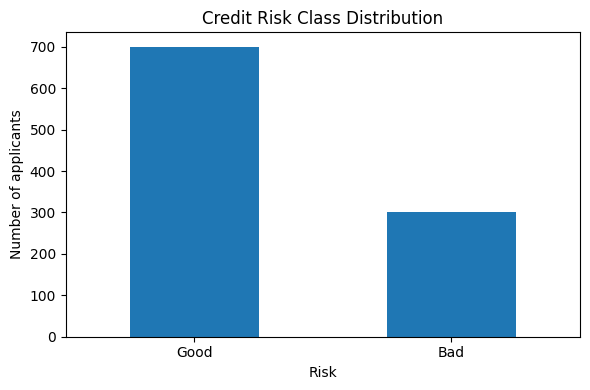

In [ ]:
display(X.describe(include="all").T)

missing = X.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

plt.figure(figsize=(6,4))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Good", "Bad"], rotation=0)
plt.ylabel("Number of applicants")
plt.title("Credit Risk Class Distribution")
plt.tight_layout()
plt.show()


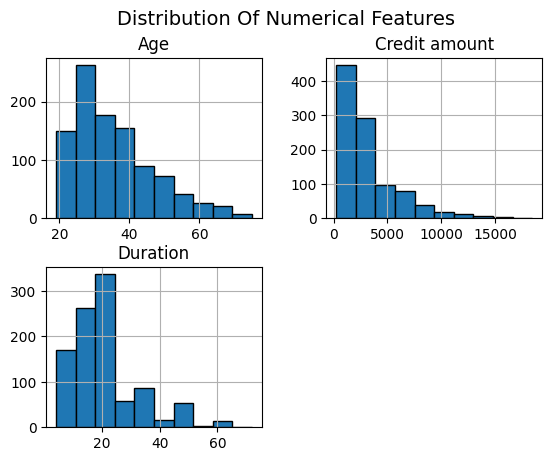

In [ ]:
df[["Age", "Credit amount", "Duration"]].hist(bins=10, edgecolor = "black")
plt.suptitle("Distribution Of Numerical Features", fontsize = 14)
plt.show()

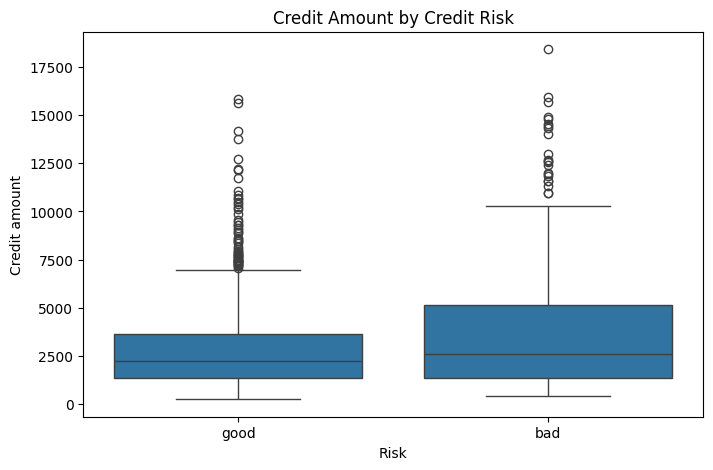

In [ ]:
# Additional EDA Plots

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Credit Amount by Risk
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Risk", y="Credit amount")
plt.title("Credit Amount by Credit Risk")
plt.show()



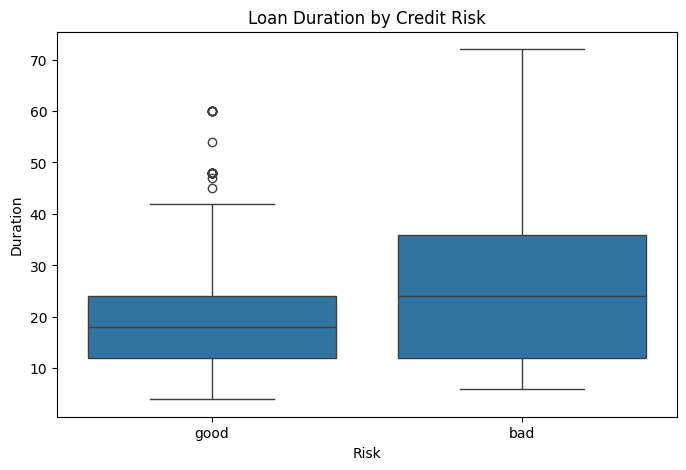

In [ ]:

# 2. Loan Duration by Risk
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Risk", y="Duration")
plt.title("Loan Duration by Credit Risk")
plt.show()



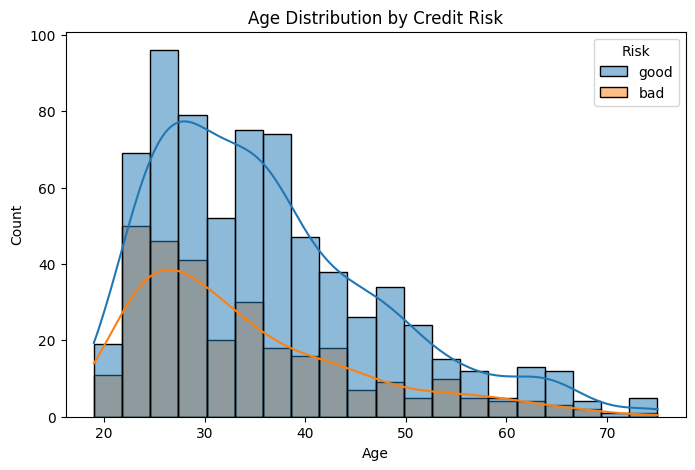

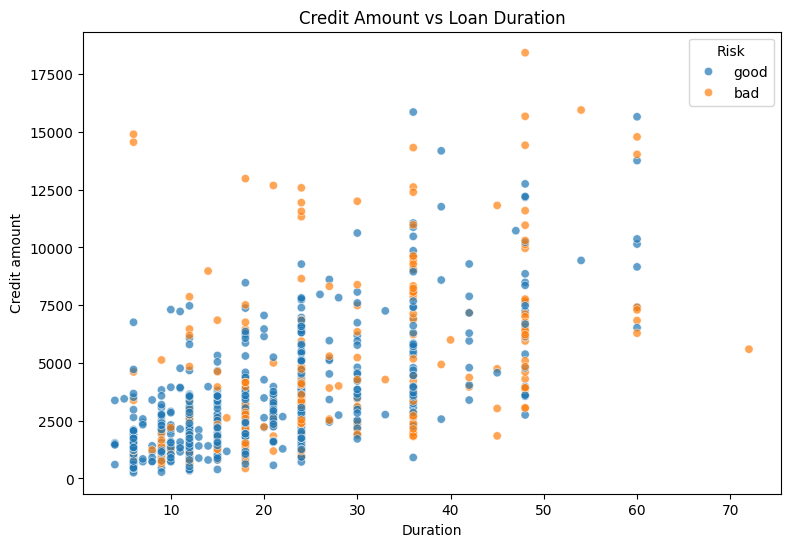

NameError: name 'risk_rate' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:

# 3. Age Distribution by Risk
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Risk", bins=20, kde=True)
plt.title("Age Distribution by Credit Risk")
plt.show()


# 4. Credit Amount vs Duration
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Duration",
    y="Credit amount",
    hue="Risk",
    alpha=0.7
)
plt.title("Credit Amount vs Loan Duration")
plt.show()




plt.figure(figsize=(8,5))
sns.barplot(x=risk_rate.values, y=risk_rate.index)
plt.xlabel("Bad Credit Rate (%)")
plt.ylabel("Saving Account")
plt.title("Bad Credit Rate by Saving Account")
plt.show()




In [ ]:
# 5. Bad Credit Rate by Checking Account
risk_rate = (
    df.groupby("Checking account")["Risk"]
    .apply(lambda x: (x == "bad").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=risk_rate.values, y=risk_rate.index)
plt.xlabel("Bad Credit Rate (%)")
plt.ylabel("Checking Account")
plt.title("Bad Credit Rate by Checking Account")
plt.show()


# 6. Bad Credit Rate by Saving Account
risk_rate = (
    df.groupby("Saving accounts")["Risk"]
    .apply(lambda x: (x == "bad").mean() * 100)
    .sort_values(ascending=False)
)

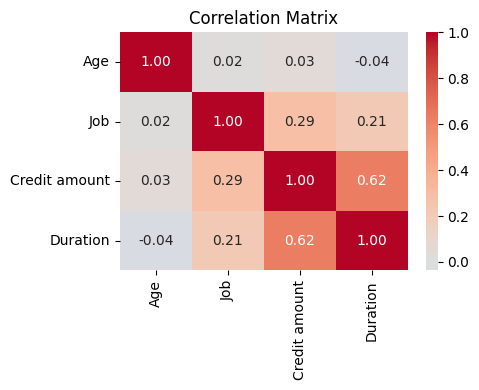

In [ ]:
# 7. Correlation Matrix
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(5,4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()




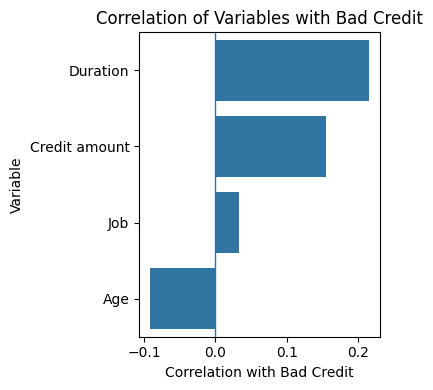

In [ ]:
# 8. Correlation with Bad Credit
df["Risk_binary"] = df["Risk"].map({
    "good": 0,
    "bad": 1
})

risk_corr = (
    df.select_dtypes(include=np.number)
    .corr()["Risk_binary"]
    .drop("Risk_binary")
    .sort_values(ascending=False)
)

plt.figure(figsize=(4,4))
sns.barplot(x=risk_corr.values, y=risk_corr.index)
plt.xlabel("Correlation with Bad Credit")
plt.ylabel("Variable")
plt.title("Correlation of Variables with Bad Credit")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FEATURE SELECTION — MUTUAL INFORMATION
# Insert BEFORE train/test split
# ============================================================

from sklearn.feature_selection import mutual_info_classif

# Create a temporary numeric version for feature selection
X_fs = X.copy()

# Encode categorical variables temporarily
for col in X_fs.select_dtypes(include="object").columns:
    X_fs[col] = X_fs[col].astype("category").cat.codes

# Handle missing values
X_fs = X_fs.fillna(-999)

# Calculate mutual information
mi_scores = mutual_info_classif(
    X_fs,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_fs.columns
).sort_values(ascending=False)

print("Feature Importance using Mutual Information:")
display(mi_scores.to_frame("MI Score"))

Feature Importance using Mutual Information:


,MI Score
Checking account,0.093892
Duration,0.035521
Housing,0.024059
Job,0.015038
Age,0.013953
Saving accounts,0.013694
Credit amount,0.009928
Sex,0.000000
Purpose,0.000000


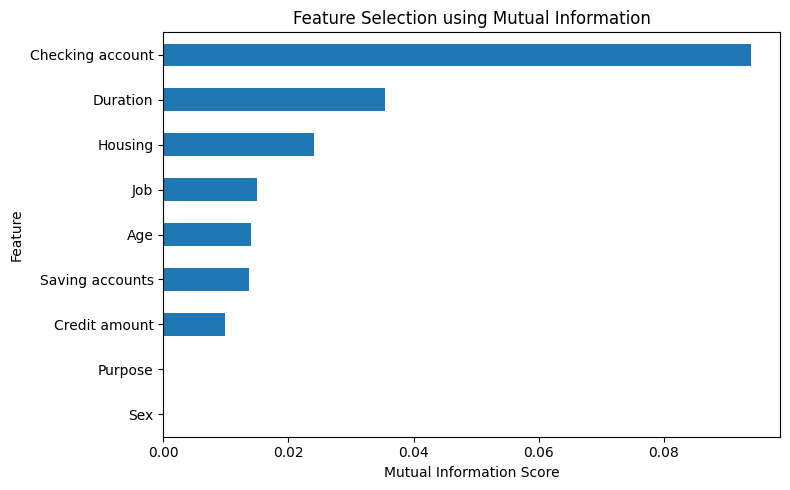

In [ ]:
# ============================================================
# MUTUAL INFORMATION FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(8, 5))

mi_scores.sort_values().plot(
    kind="barh"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Selection using Mutual Information")
plt.tight_layout()
plt.show()

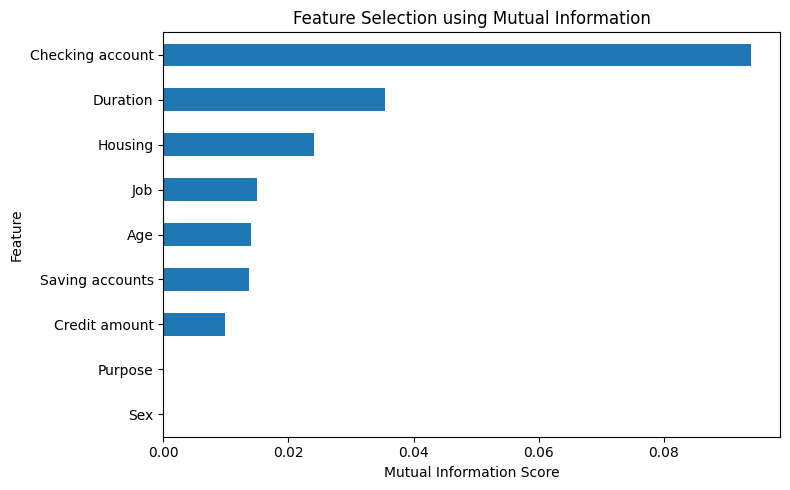

In [ ]:
# ============================================================
# MUTUAL INFORMATION FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(8, 5))

mi_scores.sort_values().plot(
    kind="barh"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Selection using Mutual Information")
plt.tight_layout()
plt.show()

,MI Score
Checking account,0.093892
Duration,0.035521
Housing,0.024059
Job,0.015038
Age,0.013953
Saving accounts,0.013694
Credit amount,0.009928
Sex,0.000000
Purpose,0.000000


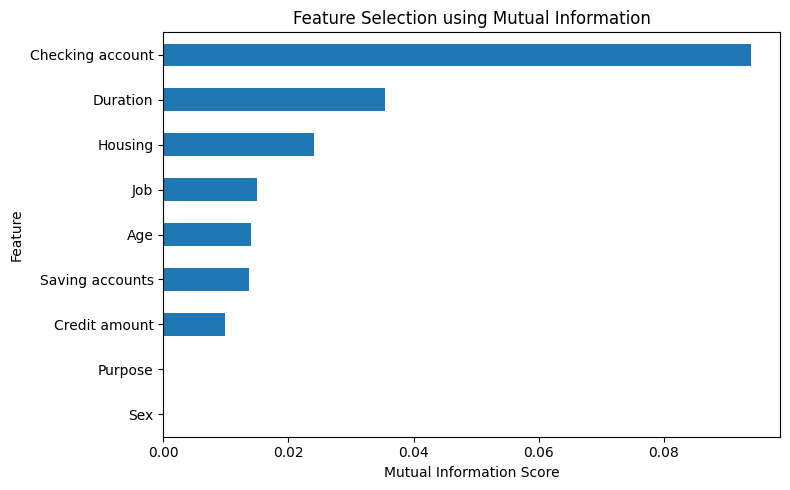

Selected Features:
['Checking account', 'Duration', 'Housing', 'Job', 'Age']

Selected 5 out of 9 features.


In [ ]:
# ============================================================
# FEATURE SELECTION — MUTUAL INFORMATION
# ============================================================

from sklearn.feature_selection import mutual_info_classif

# Temporary numeric representation for feature selection
X_fs = X.copy()

for col in X_fs.select_dtypes(include="object").columns:
    X_fs[col] = X_fs[col].astype("category").cat.codes

X_fs = X_fs.fillna(-999)

mi_scores = mutual_info_classif(
    X_fs, y, random_state=42
)

mi_scores = pd.Series(
    mi_scores, index=X_fs.columns
).sort_values(ascending=False)

display(mi_scores.to_frame("MI Score"))

plt.figure(figsize=(8, 5))
mi_scores.sort_values().plot(kind="barh")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Selection using Mutual Information")
plt.tight_layout()
plt.show()

mi_threshold = mi_scores.median()
selected_features = mi_scores[mi_scores >= mi_threshold].index.tolist()

print("Selected Features:")
print(selected_features)
print(f"\nSelected {len(selected_features)} out of {len(X.columns)} features.")

X = X[selected_features]


## 4. Train/Test Split

A stratified split preserves the good/bad credit distribution in both samples.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (800, 5)
Test : (200, 5)


## 5. Leakage-Safe Preprocessing

Instead of label-encoding categorical variables, this pipeline:

- imputes missing numerical values with the median
- imputes missing categorical values with the most frequent category
- one-hot encodes categorical variables
- standardizes numerical variables for Logistic Regression

All transformations are fitted only on training data.


In [ ]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Duration', 'Job', 'Age']
Categorical features: ['Checking account', 'Housing']


## 6. Model Comparison

We compare several models rather than assuming that one algorithm is best.

Because bad-credit cases are the economically important class, the main selection metric is **ROC-AUC**, while recall, precision and PR-AUC are also reported.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        class_weight="balanced",
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "pr_auc": "average_precision"
}

cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

cv_table = pd.DataFrame(cv_results).sort_values("ROC-AUC", ascending=False)
display(cv_table.round(3))


,Model,Accuracy,ROC-AUC,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.635,0.674,0.421,0.592,0.491,0.483
4,XGBoost,0.700,0.648,0.489,0.292,0.364,0.458
2,Random Forest,0.671,0.642,0.432,0.350,0.384,0.451
3,Extra Trees,0.662,0.622,0.432,0.400,0.414,0.414
1,Decision Tree,0.614,0.549,0.366,0.400,0.381,0.329


## 7. Hyperparameter Tuning — XGBoost

In [ ]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

xgb_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [2, 3, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)
print("Best CV ROC-AUC:", round(xgb_grid.best_score_, 4))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV ROC-AUC: 0.6674


## 8. Final Test-Set Evaluation

In [ ]:
best_model = xgb_grid.best_estimator_

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred_50 = (test_prob >= 0.50).astype(int)

metrics_50 = {
    "Accuracy": accuracy_score(y_test, test_pred_50),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "Precision": precision_score(y_test, test_pred_50, zero_division=0),
    "Recall": recall_score(y_test, test_pred_50, zero_division=0),
    "F1": f1_score(y_test, test_pred_50, zero_division=0),
    "PR-AUC": average_precision_score(y_test, test_prob)
}

display(pd.DataFrame([metrics_50]).round(4))

print(classification_report(
    y_test, test_pred_50,
    target_names=["Good Credit", "Bad Credit"],
    zero_division=0
))


,Accuracy,ROC-AUC,Precision,Recall,F1,PR-AUC
0,0.715,0.6531,0.5652,0.2167,0.3133,0.4903


              precision    recall  f1-score   support

 Good Credit       0.73      0.93      0.82       140
  Bad Credit       0.57      0.22      0.31        60

    accuracy                           0.71       200
   macro avg       0.65      0.57      0.57       200
weighted avg       0.68      0.71      0.67       200



## 9. Confusion Matrix

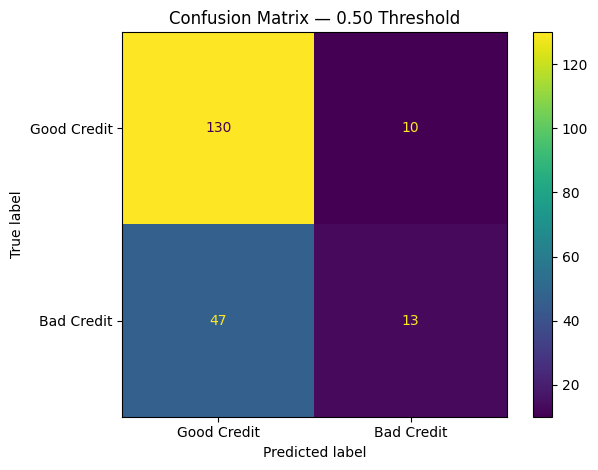

In [ ]:
cm = confusion_matrix(y_test, test_pred_50)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good Credit", "Bad Credit"]
)
disp.plot()
plt.title("Confusion Matrix — 0.50 Threshold")
plt.tight_layout()
plt.show()


## 10. ROC and Precision-Recall Curves

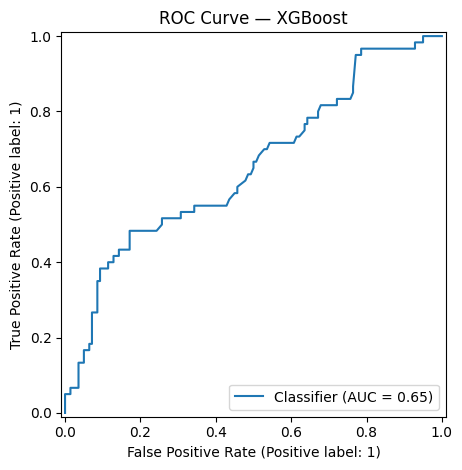

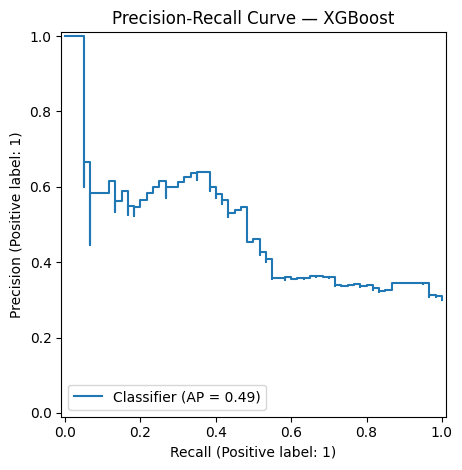

In [ ]:
RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title("ROC Curve — XGBoost")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title("Precision-Recall Curve — XGBoost")
plt.tight_layout()
plt.show()


## 11. Cost-Sensitive Threshold Selection

A credit-risk system should not automatically use a 0.50 probability threshold.

Here we assign a higher cost to **approving a bad borrower** (false negative) than to rejecting a good borrower (false positive).

These costs are illustrative and should be replaced by business-specific estimates in a real lending environment.


In [ ]:
# Illustrative costs
COST_FALSE_NEGATIVE = 5   # bad borrower incorrectly classified as good
COST_FALSE_POSITIVE = 1   # good borrower incorrectly classified as bad

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    pred = (test_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total_cost = COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp

    threshold_results.append({
        "threshold": threshold,
        "false_positive": fp,
        "false_negative": fn,
        "cost": total_cost,
        "recall_bad": recall_score(y_test, pred, zero_division=0),
        "precision_bad": precision_score(y_test, pred, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_results)
best_threshold = threshold_table.loc[threshold_table["cost"].idxmin(), "threshold"]

print("Cost-optimal threshold:", round(best_threshold, 2))
display(threshold_table.sort_values("cost").head(10).round(3))


Cost-optimal threshold: 0.19


,threshold,false_positive,false_negative,cost,recall_bad,precision_bad
9,0.19,110,2,120,0.967,0.345
8,0.18,112,2,122,0.967,0.341
7,0.17,119,2,129,0.967,0.328
6,0.16,121,2,131,0.967,0.324
4,0.14,123,2,133,0.967,0.320
5,0.15,123,2,133,0.967,0.320
3,0.13,123,2,133,0.967,0.320
2,0.12,124,2,134,0.967,0.319
0,0.10,131,1,136,0.983,0.311
1,0.11,128,2,138,0.967,0.312


In [ ]:
final_threshold = float(best_threshold)
final_pred = (test_prob >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()

print(f"Threshold: {final_threshold:.2f}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"Recall of bad-credit borrowers: {recall_score(y_test, final_pred):.3f}")
print(f"Precision of bad-credit borrowers: {precision_score(y_test, final_pred, zero_division=0):.3f}")


Threshold: 0.19
False positives: 110
False negatives: 2
Recall of bad-credit borrowers: 0.967
Precision of bad-credit borrowers: 0.345


## 12. Feature Importance

,importance
num__Duration,0.193762
cat__Checking account_moderate,0.151970
cat__Housing_own,0.147726
cat__Housing_rent,0.105699
cat__Checking account_little,0.087786
cat__Housing_free,0.083128
cat__Checking account_rich,0.081178
num__Age,0.081130
num__Job,0.067622


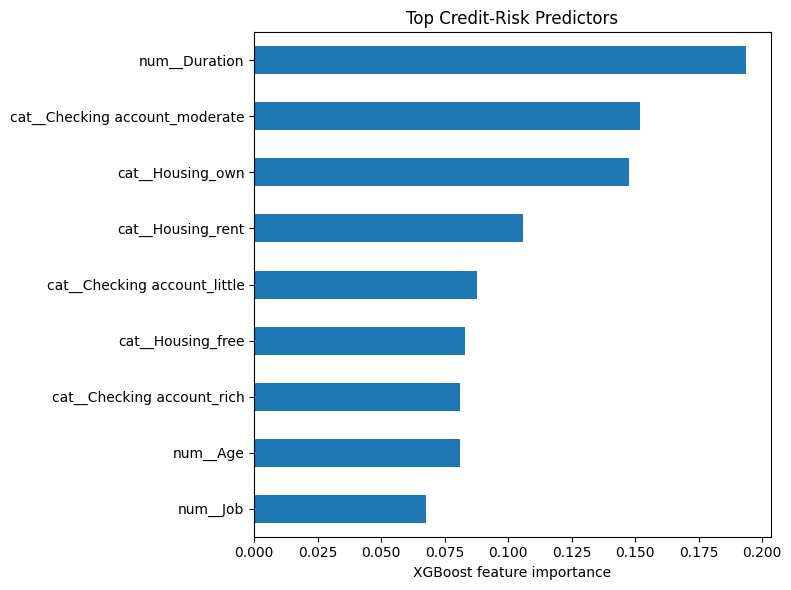

In [ ]:
# Extract transformed feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
xgb_model = best_model.named_steps["model"]

importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

display(importance.to_frame("importance"))

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.xlabel("XGBoost feature importance")
plt.title("Top Credit-Risk Predictors")
plt.tight_layout()
plt.show()


## 13. SHAP Explainability

SHAP helps explain **why** individual predictions move toward good or bad credit risk.

For large datasets, use a sample for faster visualization.


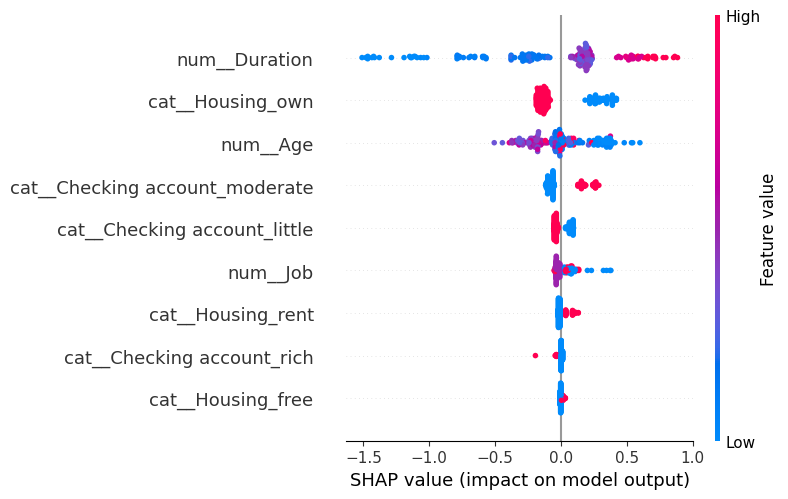

In [ ]:
try:
    import shap

    X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)
    X_test_transformed = pd.DataFrame(
        X_test_transformed,
        columns=feature_names,
        index=X_test.index
    )

    sample_n = min(300, len(X_test_transformed))
    shap_sample = X_test_transformed.sample(sample_n, random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(shap_values, shap_sample, show=False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("SHAP could not be generated in this environment:", e)


## 14. Applicant-Level Risk Score

In [ ]:
def predict_credit_risk(applicant_df, model=best_model, threshold=final_threshold):
    """Return probability and risk category for one or more applicants."""
    probability_bad = model.predict_proba(applicant_df)[:, 1]
    prediction = (probability_bad >= threshold).astype(int)

    result = applicant_df.copy()
    result["probability_bad_credit"] = probability_bad
    result["prediction"] = np.where(prediction == 1, "Bad Credit", "Good Credit")
    result["risk_band"] = pd.cut(
        probability_bad,
        bins=[-np.inf, 0.30, 0.60, np.inf],
        labels=["Low", "Medium", "High"]
    )
    return result

# Example:
# predict_credit_risk(X_test.iloc[[0]])


## 15. Save the Model for Streamlit

In [ ]:
model_artifact = {
    "model": best_model,
    "threshold": final_threshold,
    "risk_band_cutoffs": [0.30, 0.60],
    "target_definition": "1 = Bad Credit, 0 = Good Credit"
}

joblib.dump(model_artifact, "credit_risk_model.pkl")
print("Saved: credit_risk_model.pkl")


Saved: credit_risk_model.pkl


## 16. Streamlit Integration Example

Use the saved `credit_risk_model.pkl` in a Streamlit application.

The application should collect the same applicant fields used in `X`, pass them to `predict_proba()`, and display:

- Probability of bad credit
- Risk band
- Good/Bad credit classification
- Decision threshold

For production use, the threshold and risk-band cutoffs should be calibrated using business loss estimates and validated on an appropriate out-of-time sample.


In [ ]:
# Example Streamlit-side logic
#
# artifact = joblib.load("credit_risk_model.pkl")
# model = artifact["model"]
# threshold = artifact["threshold"]
#
# probability_bad = model.predict_proba(applicant_df)[:, 1][0]
#
# if probability_bad < 0.30:
#     risk_band = "Low"
# elif probability_bad < 0.60:
#     risk_band = "Medium"
# else:
#     risk_band = "High"
#
# st.metric("Probability of Bad Credit", f"{probability_bad:.1%}")
# st.write("Risk Band:", risk_band)


In [ ]:
%%writefile app.py
def greet(name):
    return f"Hello, {name}!"

print(greet("World"))

Writing app.py


In [ ]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

# Key Takeaways

This version treats the project as a **credit-risk decision problem**, not only a classification exercise.

The main additions are:

1. **Leakage-safe preprocessing**
2. **Multiple model comparison**
3. **Cross-validation and XGBoost tuning**
4. **ROC-AUC, PR-AUC, precision, recall and F1**
5. **Confusion matrix**
6. **Feature importance**
7. **SHAP explainability**
8. **Probability-based risk scoring**
9. **Cost-sensitive threshold selection**
10. **Streamlit-ready saved pipeline**
